# Colab Environment Smoke Test — EfficientDet-D0 Restoration

**Smart Sniper Spotter · Target Detection Module · Stage 2 migration validation**

This notebook validates the hypothesis that NB3's restoration failure on Kaggle
was caused by the TF 2.19 / Keras 3 / numpy 2 + seven-shim stack, not by the
EfficientDet-D0 + COCO-detection-checkpoint pipeline itself.

**Why this matters for deployment.** NB2 trained cleanly on Kaggle but
plateaued at mAP=0.278 / mAP_small=0.076, which doesn't meet the system's
recall/precision targets at 5–40m range. EfficientDet-D0 is the
architecture-side bet for better small-target performance. If its
restoration is broken end-to-end, that bet can't be evaluated.

**Setup architecture — two Python interpreters.** Colab's notebook kernel
hardcodes its own Python (currently 3.12) and condacolab cannot rebind that
kernel to a different interpreter. So:

| Where | Python | Used for |
|---|---|---|
| Notebook kernel | Colab 3.12 | Orchestration: file I/O, JSON parsing, plotting |
| `!python` in shell magic | Conda 3.11 | **All TF/OD-API work**, in subprocess |

This separation actually helps. The OD-API `model_main_tf2.py` invokes
`absl.app.run()` which can only be called once per Python process; running
it in subprocess means the kernel stays clean across multiple training calls.
The kernel-side Python 3.12 never imports TF, so its newer numpy 2 / Keras 3
can't contaminate the training stack.

Final training-side stack (in conda env, used via `!python`):
Python 3.11 / TF 2.13.1 (cuda118 build) / Keras 2.13 / numpy 1.24 /
protobuf 3.20. **No compatibility shims.**

**Architecture:** EfficientDet-D0 (SSD framework + EfficientNet-B0 + BiFPN),
1-class person head, COCO `fine_tune_checkpoint_type: "detection"`. Same
Lite-style modifications as NB3 (RELU_6 + depthwise box predictor +
frozen BN).

**Input size:** **512×512** (D0 canonical). Restoration is by variable name,
not shape, so this validates restoration at any input size including the
384 NB3 actually used.

**Data:** ~2K COCO val2017 person-containing images downloaded directly in
Colab, written to TFRecords in OD-API format. This isolates the test from
Stage 2 TFRecord transfer logistics. Distribution is broadly representative
of person detection; not identical to NB1's outdoor + WiderPerson merge.
That's fine — the question is restoration mechanics, not final mAP.

**Two-gate decision protocol:**

| Gate | Step | Condition | Action |
|---|---|---|---|
| Early kill | 500 | `classification_loss ≥ 1.0` | Stop. Env hypothesis is dead. |
| Confirmed pass | 5000 | `classification_loss < 0.5` | Env is the fix. Proceed with full migration. |

A properly-restored COCO-detection checkpoint with a 1-class head should land
well under the ~1.13 random-init prior by step 100 (backbone + FPN + box-regression
heads restored cleanly; only the class head is reinitialized).

**Prerequisites before running:**
- **Colab Pro** subscription
- **Runtime > Change runtime type > T4 GPU** (not L4 or A100 — TF 2.13's
  cuda118 build is tested against T4-class hardware on Colab)

**Total runtime estimate (T4):**
- Cell #1 (condacolab install + auto-restart): ~2 min
- Cell #2 (TF 2.13 + GPU install via mamba): ~6–8 min
- Cell #3 (OD API install): ~2 min
- Cell #4 (download COCO val + write TFRecords): ~8 min
- Cells #5–#7: ~1 min
- Cell #8 (Phase 1, 500 steps): ~4 min
- Cell #10 (Phase 2, to 5000): ~25–35 min if reached

Worst case if early-kill triggers: ~25 min total. Worst case to completion:
~55 min.


## 1. Install condacolab

Swaps the base Python interpreter to 3.10 via miniforge and auto-restarts the kernel. After restart, proceed to Cell #2.


In [1]:
# Cell #1: Install condacolab.
#
# Colab Pro currently ships Python 3.12 + TF 2.20 + numpy 2 + Keras 3 + CUDA 12.
# TF 2.13 has no wheel for Python 3.12, and its CUDA 11.8 binding doesn't
# match Colab's CUDA 12 driver layer. We can't downgrade the base interpreter
# with pip alone — we need a conda environment.
#
# condacolab installs miniforge in /usr/local, makes Python 3.10 the runtime
# default, and automatically restarts the kernel. After the restart, !pip,
# !python, !mamba all operate on the conda env.
#
# This cell ends with an automatic kernel restart. That's expected. After
# restart, the kernel disconnects briefly and reconnects, then run Cell #2.
#
# Why not try pip downgrade again: the previous attempt uninstalled TF 2.20
# without successfully installing TF 2.13 (no Python 3.12 wheel), leaving
# the kernel TF-less. condacolab swaps the Python interpreter itself, which
# is the only correct fix.

import sys
print(f"Pre-install Python: {sys.version.split()[0]}")
print(f"Pre-install platform: Colab Pro / free, T4 GPU expected")

print("\n>> Installing condacolab...")
!pip install -q condacolab

print("\n>> Running condacolab.install() — this will auto-restart the runtime.")
print("   After restart, the kernel disconnects for ~30s, then reconnects.")
print("   When it's back, proceed to Cell #2.\n")

import condacolab
condacolab.install()
# Execution stops here. The kernel restarts. Cell #2 picks up after.


Pre-install Python: 3.12.13
Pre-install platform: Colab Pro / free, T4 GPU expected

>> Installing condacolab...

>> Running condacolab.install() — this will auto-restart the runtime.
   After restart, the kernel disconnects for ~30s, then reconnects.
   When it's back, proceed to Cell #2.

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:08
🔁 Restarting kernel...


## 2. Install TF 2.13 GPU (conda-forge cuda118 build)

Brings TF 2.13.1 + bundled CUDA 11.8 + cuDNN + Keras 2.13 + numpy 1.24 + protobuf 3.20.


In [1]:
# Cell #2: Verify condacolab installed correctly, then install TF 2.13 GPU
# into the conda env via mamba. All TF verification runs via !python
# subprocess — the notebook kernel itself stays on Colab's Python 3.12 and
# never imports TF.

import os
import subprocess

print(">> Notebook kernel Python (orchestrator):")
import sys
print(f"   {sys.version.split()[0]}  ({sys.executable})")

print("\n>> Shell `python` (training subprocess) — should be conda 3.11:")
!which python
!python --version

# Sanity check that conda env is actually usable from shell magic.
# The conda env was created by condacolab. mamba and conda live in /usr/local/bin.
result = subprocess.run(['/usr/local/bin/python', '--version'],
                        capture_output=True, text=True)
assert 'Python 3.1' in result.stdout, \
    f"Shell python is not the conda env! Got: {result.stdout!r}. " \
    "Re-run Cell #1 from a fresh runtime."
print(f"   ✓ Shell python: {result.stdout.strip()}")

print("\n>> Installing TF 2.13.1 GPU (conda-forge cuda118 build) via mamba...")
print("   This brings TF 2.13.1 + bundled CUDA 11.8 + cuDNN + Keras 2.13.")
print("   Expected ~6–8 min. The bundled CUDA tarball is ~700MB.")

# CONDA_OVERRIDE_CUDA tells the resolver to pick the cuda118 build even if
# the host driver reports CUDA 12.x. The cuda118-bundled TF brings its own
# libcudart / libcudnn in the conda env, so we don't depend on Colab's
# system CUDA libs for TF.
#
# `python=3.11` is pinned explicitly because the conda env's current Python
# is already 3.11 (per Cell #1's miniforge install). If we don't pin, the
# resolver could try to upgrade Python and break the env.

os.environ["CONDA_OVERRIDE_CUDA"] = "11.8"

# Clear the stale `python=3.12` pin that condacolab's miniforge install leaves
# behind. Without this, mamba refuses to do anything because the pin file says
# 3.12 but the env actually has 3.11. Idempotent — re-running is harmless.
print("\n>> Clearing stale conda pin (python=3.12)...")
!conda config --env --remove-key pinned_packages 2>/dev/null || true
!rm -f /usr/local/conda-meta/pinned

# Single mamba install. Important notes on what's NOT pinned here:
#   - protobuf: conda-forge's TF 2.13.1 py311 build requires libprotobuf 4.x.
#     Pinning protobuf<4 causes the solver to reject the only py311 build.
#     The OD API's *_pb2.py gencode is regenerated by protoc anyway (see
#     Cell #3), so the runtime protobuf version doesn't matter for us.
#   - keras: TF 2.13 bundles its own Keras 2.x as tf.keras; no separate pin.
#   - numpy: conda-forge picks numpy 1.26.4, which is fine.
!mamba install -y -n base -c conda-forge \
    'python=3.11' \
    'tensorflow=2.13.1=cuda118py311*' 2>&1 | tail -15

# Now verify TF in the conda env via subprocess. This is the actual test —
# we never `import tensorflow` in the kernel.
print("\n>> Verifying TF in conda env (via subprocess)...")

verify_script = r"""
import sys
import tensorflow as tf
import numpy as np
import google.protobuf
import keras

print(f"Python:     {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {keras.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"protobuf:   {google.protobuf.__version__}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")

assert tf.__version__.startswith('2.13.'), f'TF: {tf.__version__}'
assert keras.__version__.startswith('2.'), f'Keras: {keras.__version__}'
assert np.__version__.startswith('1.'), f'numpy: {np.__version__}'
# protobuf 4.x is what conda-forge ships with TF 2.13.1 py311 build; 3.x
# also fine for older builds.
assert google.protobuf.__version__.startswith(('3.', '4.')), \
    f'protobuf: {google.protobuf.__version__}'

print('\nGPUs:')
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    print(f'  {g}')
assert len(gpus) >= 1, 'No GPU visible to TF in conda env.'

# Exercise libcudart + libcudnn via a real matmul.
with tf.device('/GPU:0'):
    a = tf.random.normal([512, 512])
    b = tf.random.normal([512, 512])
    c = tf.matmul(a, b)
    _ = c.numpy()
print(f'\nGPU matmul OK: shape={c.shape}, mean={float(tf.reduce_mean(c)):.4f}')
print('\nOK')
"""

# Use -u for unbuffered output so we see progress in real time.
result = subprocess.run(['/usr/local/bin/python', '-u', '-c', verify_script],
                        capture_output=True, text=True, timeout=300)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:")
    print(result.stderr)
    raise RuntimeError(
        "TF verification in conda env failed. Read the stderr above carefully — "
        "if it mentions libcuda.so or 'No GPU', the conda env's TF can't see "
        "Colab's GPU driver. If it mentions a version mismatch, mamba installed "
        "a different TF than asked for."
    )
assert 'OK' in result.stdout, "Verify script didn't print OK marker."

print("\n✓ TF 2.13 GPU stack verified in conda env. No shims will be needed.")
print("  Subsequent training cells will use this same `!python` interpreter.")


>> Notebook kernel Python (orchestrator):
   3.12.13  (/usr/bin/python3.real)

>> Shell `python` (training subprocess) — should be conda 3.11:
/usr/local/bin/python
Python 3.11.11
   ✓ Shell python: Python 3.11.11

>> Installing TF 2.13.1 GPU (conda-forge cuda118 build) via mamba...
   This brings TF 2.13.1 + bundled CUDA 11.8 + cuDNN + Keras 2.13.
   Expected ~6–8 min. The bundled CUDA tarball is ~700MB.

>> Clearing stale conda pin (python=3.12)...



Looking for: ['python=3.11', 'tensorflow==2.13.1[build=cuda118py311*]']


Preparing transaction: - \ | / - \ done
Verifying transaction: / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \

## 3. Install Object Detection API (canonical path, no shims)


In [2]:
# Cell #3: Install the TF2 Object Detection API into the conda env.
#
# This cell is load-bearing — its install order and defensive pins are the
# result of debugging at least eight distinct failure modes. Do NOT remove
# pins or reorder without understanding what each one guards against.
#
# Critical invariants enforced here:
#   1. TF stays at 2.13.x. Without `tensorflow==2.13.*` pinned in every pip
#      call, transitive deps (tensorflow-hub, tensorflow-model-optimization,
#      pandas, etc.) will resolve to "newest compatible" versions and silently
#      upgrade TF to 2.19+, which has Keras 3 and breaks the OD API.
#   2. numpy stays at 1.x. lvis>=0.5.4, scipy>=1.13, pandas>=2.2 all require
#      numpy 2.x. If any sneaks in, TF's C extensions crash at import with
#      "AttributeError: _ARRAY_API not found".
#   3. pyyaml is >=5.1 (no upper bound). tf-models-official asks for pyyaml<6,
#      but PyYAML 5.4.1 fails to build from source on Python 3.11. pyyaml 6.x
#      works fine in practice.
#   4. MPLBACKEND is forced to 'Agg' for every subprocess. Colab's Jupyter sets
#      MPLBACKEND='module://matplotlib_inline.backend_inline' which leaks into
#      `!python` subprocesses and crashes matplotlib (the inline backend isn't
#      installed in the conda env).

import os
import subprocess

# Clear Jupyter's matplotlib backend so subprocesses don't inherit it.
os.environ['MPLBACKEND'] = 'Agg'

TF_MODELS = "/content/tf_models"
PIP = "/usr/local/bin/pip"  # conda env's pip

# All OD API runtime Python deps in one pip call. The order matters:
# tensorflow + numpy + protobuf pins go FIRST so pip's resolver sees them
# as hard constraints before considering any other package's loose
# version ranges.
print(">> Installing OD API runtime Python deps (with defensive TF/numpy pins)...")
!{PIP} install -q --no-cache-dir \
    'tensorflow==2.13.*' \
    'numpy<2' \
    'protobuf<5' \
    'scipy<1.13' \
    'pyyaml>=5.1' \
    'pyparsing>=3' \
    'sacrebleu<=2.2.0' \
    'tensorflow-io==0.34.0' \
    'tensorflow-hub<0.16' \
    'tensorflow-model-optimization<0.8' \
    'pandas<2.2' \
    'avro-python3' \
    'contextlib2' \
    'tf-slim==1.1.0' \
    'pycocotools' \
    'lvis<0.5.4' \
    'pillow' \
    'lxml' \
    'Cython' \
    'matplotlib' 2>&1 | tail -5

print("\n>> Installing tf-models-official==2.13.0 (--no-deps)...")
!{PIP} install -q --no-deps --no-cache-dir \
    'tf-models-official==2.13.0' 2>&1 | tail -3

# Sanity check: confirm pip didn't clobber TF or numpy during the install.
# This is defense-in-depth — the pins above should prevent it, but if a future
# pip release loosens its resolver behavior, this assertion catches it before
# the OD API import (which would otherwise fail with a confusing Keras 3 error).
print("\n>> Sanity check: confirm TF is still 2.13.x and numpy is still 1.x...")
!/usr/local/bin/python -c "import tensorflow as tf; import numpy as np; assert tf.__version__.startswith('2.13.'), f'TF clobbered: {tf.__version__}'; assert np.__version__.startswith('1.'), f'numpy clobbered: {np.__version__}'; print(f'TF={tf.__version__} numpy={np.__version__} OK')"

# Clone tensorflow/models (the OD API source).
if not os.path.isdir(os.path.join(TF_MODELS, ".git")):
    print("\n>> Cloning tensorflow/models (shallow)...")
    !git clone --depth 1 https://github.com/tensorflow/models.git "{TF_MODELS}" 2>&1 | tail -3
else:
    print("\n>> tensorflow/models already cloned, skipping.")

# Use the conda env's protoc.
print("\n>> protoc binary in conda env:")
!which protoc
!protoc --version

os.chdir(f"{TF_MODELS}/research")
print("\n>> Compiling OD API protos...")
!protoc object_detection/protos/*.proto --python_out=. 2>&1 | tail -5

import glob
n_pb2 = len(glob.glob("object_detection/protos/*_pb2.py"))
assert n_pb2 > 10, f"Expected many *_pb2.py files; only found {n_pb2}. protoc failed."
print(f"   Generated {n_pb2} *_pb2.py files.")

# Install OD API into the conda env.
!cp object_detection/packages/tf2/setup.py .

print("\n>> Installing object_detection (--no-deps; we control versions)...")
!{PIP} install -q --no-deps . 2>&1 | tail -5

os.chdir("/content")

# Final TF/numpy sanity check before OD API import test.
print("\n>> Final TF/numpy sanity check before OD API import test...")
!/usr/local/bin/python -c "import tensorflow as tf; import numpy as np; assert tf.__version__.startswith('2.13.'), f'TF clobbered post-OD-install: {tf.__version__}'; assert np.__version__.startswith('1.'), f'numpy clobbered: {np.__version__}'; print(f'TF={tf.__version__} numpy={np.__version__} OK')"

# Verify OD API imports work in the conda env (via subprocess).
print("\n>> Verifying OD API imports (via subprocess)...")

verify_od_script = r"""
import os
from object_detection.utils import config_util
from object_detection.utils import label_map_util
from object_detection.builders import model_builder
from object_detection import inputs
print('config_util, label_map_util, model_builder, inputs — all OK.')

# EfficientDet feature extractor (needs real efficientnet_model).
from object_detection.models import ssd_efficientnet_bifpn_feature_extractor as _effdet_fe
_fe_classes = [c for c in dir(_effdet_fe) if c.startswith('SSDEfficient')]
assert _fe_classes, 'EfficientDet feature extractor exposed no classes.'
print(f'EfficientDet feature extractor classes: {len(_fe_classes)} found')

# Real efficientnet_model (NB3's import-time blocker on Kaggle).
from official.legacy.image_classification.efficientnet import efficientnet_model
assert hasattr(efficientnet_model, 'EfficientNet'), \
    'efficientnet_model missing EfficientNet class.'
print(f'efficientnet_model: real module at {efficientnet_model.__file__}')

# Locate model_main_tf2.py — print path so kernel can capture it.
import object_detection as _od_pkg
od_root = os.path.dirname(_od_pkg.__file__)
model_main = os.path.join(od_root, 'model_main_tf2.py')
assert os.path.exists(model_main), f'model_main_tf2.py missing at {model_main}'
print(f'MODEL_MAIN={model_main}')
"""

result = subprocess.run(['/usr/local/bin/python', '-c', verify_od_script],
                        capture_output=True, text=True, timeout=120,
                        env={**os.environ, 'MPLBACKEND': 'Agg'})
print(result.stdout)
if result.returncode != 0:
    print("STDERR:")
    print(result.stderr)
    raise RuntimeError("OD API verification failed. See stderr above.")

# Extract MODEL_MAIN path from subprocess output for use in later cells.
MODEL_MAIN = None
for line in result.stdout.splitlines():
    if line.startswith('MODEL_MAIN='):
        MODEL_MAIN = line.split('=', 1)[1].strip()
        break
assert MODEL_MAIN and os.path.exists(MODEL_MAIN), \
    f"Could not extract MODEL_MAIN from subprocess output. Got: {MODEL_MAIN}"
print(f"\nCaptured for later use: MODEL_MAIN = {MODEL_MAIN}")

print("\n✓ OD API installed and importable on the canonical stack (conda env).")


>> Installing OD API runtime Python deps (with defensive TF/numpy pins)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 313.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 261.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 459.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 317.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.8/799.8 kB 729.4 MB/s eta 0:00:00

>> Installing tf-models-official==2.13.0 (--no-deps)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.9 MB/s eta 0:00:00

>> Sanity check: confirm TF is still 2.13.x and numpy is still 1.x...
2026-05-18 11:49:17.605813: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate com

## 4. Build the smoke-test dataset

COCO val2017 person subset → ~2000 examples → TFRecords.


In [3]:
# Cell #4: Download a small COCO val2017 person subset and write TFRecords.
#
# Strategy: ~2000 val2017 images that contain at least one person, split
# 80/20 train/val, write 4 train shards + 1 val shard.
#
# Split between kernel and subprocess:
#   - Kernel (Python 3.12): downloads COCO, parses JSON, samples image IDs,
#     writes a JSON "manifest" describing each split's image IDs.
#   - Subprocess (Python 3.11, has TF 2.13): reads the manifest and writes
#     the TFRecords in OD-API tf.train.Example format.
#
# Total download: ~1.3GB (val2017.zip ~1GB + annotations ~241MB).

import os
import json
import random
import subprocess

DATA_ROOT = "/content/smoke_data"
COCO_DIR = os.path.join(DATA_ROOT, "coco")
TFRECORD_DIR = os.path.join(DATA_ROOT, "tfrecords")
LABEL_MAP_PATH = os.path.join(DATA_ROOT, "label_map.pbtxt")
MANIFEST_PATH = os.path.join(DATA_ROOT, "manifest.json")

os.makedirs(COCO_DIR, exist_ok=True)
os.makedirs(TFRECORD_DIR, exist_ok=True)

VAL_IMAGES_URL = "http://images.cocodataset.org/zips/val2017.zip"
ANNOTATIONS_URL = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"

VAL_IMAGES_DIR = os.path.join(COCO_DIR, "val2017")
INSTANCES_JSON = os.path.join(COCO_DIR, "annotations/instances_val2017.json")

if not os.path.isdir(VAL_IMAGES_DIR):
    print(">> Downloading val2017 images (~1GB)...")
    !wget -q --show-progress -O /content/val2017.zip "{VAL_IMAGES_URL}"
    print("   Extracting...")
    !unzip -q /content/val2017.zip -d "{COCO_DIR}"
    !rm /content/val2017.zip
else:
    print(">> val2017 already extracted.")

if not os.path.exists(INSTANCES_JSON):
    print("\n>> Downloading annotations (~241MB)...")
    !wget -q --show-progress -O /content/anns.zip "{ANNOTATIONS_URL}"
    print("   Extracting (only val annotations)...")
    !unzip -qo /content/anns.zip "annotations/instances_val2017.json" -d "{COCO_DIR}"
    !rm /content/anns.zip
else:
    print(">> Annotations already present.")

# Parse annotations in the kernel — no TF needed for JSON.
print("\n>> Parsing annotations and filtering for person...")
with open(INSTANCES_JSON) as f:
    coco = json.load(f)

PERSON_CAT_ID = 1
img_index = {img["id"]: img for img in coco["images"]}

img_to_anns = {}
for ann in coco["annotations"]:
    if ann["category_id"] != PERSON_CAT_ID:
        continue
    if ann.get("iscrowd", 0) == 1:
        continue
    x, y, w, h = ann["bbox"]
    if w <= 1 or h <= 1:
        continue
    img_to_anns.setdefault(ann["image_id"], []).append([x, y, w, h])

person_image_ids = sorted(img_to_anns.keys())
print(f"   val2017 images with ≥1 person: {len(person_image_ids)}")

N_SAMPLES = 2000
random.seed(42)
if len(person_image_ids) > N_SAMPLES:
    sampled_ids = sorted(random.sample(person_image_ids, N_SAMPLES))
else:
    sampled_ids = person_image_ids
print(f"   Sampled: {len(sampled_ids)} images")

random.shuffle(sampled_ids)
split = int(0.8 * len(sampled_ids))
train_ids = sampled_ids[:split]
val_ids = sampled_ids[split:]
print(f"   Train: {len(train_ids)}  Val: {len(val_ids)}")

# Write manifest the subprocess will read.
manifest = {
    "val_images_dir": VAL_IMAGES_DIR,
    "tfrecord_dir": TFRECORD_DIR,
    "train_ids": train_ids,
    "val_ids": val_ids,
    "img_index": {str(k): v for k, v in img_index.items() if k in sampled_ids},
    "img_to_anns": {str(k): v for k, v in img_to_anns.items() if k in sampled_ids},
    "n_train_shards": 4,
    "n_val_shards": 1,
}
with open(MANIFEST_PATH, "w") as f:
    json.dump(manifest, f)
print(f"\n>> Wrote manifest: {MANIFEST_PATH} ({os.path.getsize(MANIFEST_PATH)/1e6:.1f} MB)")

# Subprocess script: TFRecord writing requires TF, so runs in conda env.
write_script = r"""
import io, json, os, sys
import tensorflow as tf
from PIL import Image

manifest_path = sys.argv[1]
with open(manifest_path) as f:
    M = json.load(f)

VAL_IMAGES_DIR = M['val_images_dir']
TFRECORD_DIR = M['tfrecord_dir']
img_index = {int(k): v for k, v in M['img_index'].items()}
img_to_anns = {int(k): v for k, v in M['img_to_anns'].items()}


def _bytes_feature(v): return tf.train.Feature(bytes_list=tf.train.BytesList(value=[v]))
def _bytes_list_feature(vs): return tf.train.Feature(bytes_list=tf.train.BytesList(value=vs))
def _int64_feature(v): return tf.train.Feature(int64_list=tf.train.Int64List(value=[v]))
def _int64_list_feature(vs): return tf.train.Feature(int64_list=tf.train.Int64List(value=vs))
def _float_list_feature(vs): return tf.train.Feature(float_list=tf.train.FloatList(value=vs))


def make_example(image_id):
    info = img_index[image_id]
    fname = info['file_name']
    img_path = os.path.join(VAL_IMAGES_DIR, fname)
    with open(img_path, 'rb') as f:
        encoded = f.read()
    pil = Image.open(io.BytesIO(encoded))
    width, height = pil.size

    xmins, ymins, xmaxs, ymaxs = [], [], [], []
    classes, classes_text = [], []
    for x, y, w, h in img_to_anns[image_id]:
        xmin = max(0.0, x / width); ymin = max(0.0, y / height)
        xmax = min(1.0, (x + w) / width); ymax = min(1.0, (y + h) / height)
        if xmax <= xmin or ymax <= ymin:
            continue
        xmins.append(xmin); ymins.append(ymin)
        xmaxs.append(xmax); ymaxs.append(ymax)
        classes.append(1); classes_text.append(b'person')
    if not xmins:
        return None

    feature = {
        'image/height': _int64_feature(height),
        'image/width': _int64_feature(width),
        'image/filename': _bytes_feature(fname.encode()),
        'image/source_id': _bytes_feature(str(image_id).encode()),
        'image/encoded': _bytes_feature(encoded),
        'image/format': _bytes_feature(b'jpeg'),
        'image/object/bbox/xmin': _float_list_feature(xmins),
        'image/object/bbox/xmax': _float_list_feature(xmaxs),
        'image/object/bbox/ymin': _float_list_feature(ymins),
        'image/object/bbox/ymax': _float_list_feature(ymaxs),
        'image/object/class/label': _int64_list_feature(classes),
        'image/object/class/text': _bytes_list_feature(classes_text),
    }
    return tf.train.Example(features=tf.train.Features(feature=feature))


def write_shards(image_ids, prefix, n_shards):
    writers = [
        tf.io.TFRecordWriter(
            os.path.join(TFRECORD_DIR, f'{prefix}-{i:05d}-of-{n_shards:05d}.tfrecord'))
        for i in range(n_shards)
    ]
    written, skipped = 0, 0
    for idx, image_id in enumerate(image_ids):
        ex = make_example(image_id)
        if ex is None:
            skipped += 1
            continue
        writers[idx % n_shards].write(ex.SerializeToString())
        written += 1
    for w in writers:
        w.close()
    return written, skipped


print('Writing TFRecords...')
n_train, skip_train = write_shards(M['train_ids'], 'train', M['n_train_shards'])
n_val, skip_val = write_shards(M['val_ids'], 'val', M['n_val_shards'])
print(f'Train: {n_train} written, {skip_train} skipped')
print(f'Val:   {n_val} written, {skip_val} skipped')
"""

print("\n>> Writing TFRecords in conda env (via subprocess)...")
result = subprocess.run(
    ['/usr/local/bin/python', '-u', '-c', write_script, MANIFEST_PATH],
    capture_output=True, text=True, timeout=600)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:")
    print(result.stderr)
    raise RuntimeError("TFRecord writing subprocess failed.")

# Label map (kernel-side; pure text I/O).
with open(LABEL_MAP_PATH, "w") as f:
    f.write('item {\n  id: 1\n  name: "person"\n  display_name: "person"\n}\n')
print(f">> Label map: {LABEL_MAP_PATH}")

# Sanity-check shard count and total size.
import glob
train_records = sorted(glob.glob(os.path.join(TFRECORD_DIR, "train-*.tfrecord")))
val_records = sorted(glob.glob(os.path.join(TFRECORD_DIR, "val-*.tfrecord")))
total_mb = sum(os.path.getsize(p) for p in train_records + val_records) / 1e6
print(f">> Resolved patterns: {len(train_records)} train, {len(val_records)} val")
print(f"   Total TFRecord size: {total_mb:.1f} MB")
assert len(train_records) == 4, f"Expected 4 train shards, got {len(train_records)}"
assert len(val_records) == 1, f"Expected 1 val shard, got {len(val_records)}"


>> Downloading val2017 images (~1GB)...
/content/val2017.zi 100%[===================>] 777.80M  60.4MB/s    in 13s     
   Extracting...

>> Downloading annotations (~241MB)...
/content/anns.zip   100%[===================>] 241.19M  61.8MB/s    in 4.3s    
   Extracting (only val annotations)...

>> Parsing annotations and filtering for person...
   val2017 images with ≥1 person: 2693
   Sampled: 2000 images
   Train: 1600  Val: 400

>> Wrote manifest: /content/smoke_data/manifest.json (0.9 MB)

>> Writing TFRecords in conda env (via subprocess)...
Writing TFRecords...
Train: 1600 written, 0 skipped
Val:   400 written, 0 skipped

>> Label map: /content/smoke_data/label_map.pbtxt
>> Resolved patterns: 4 train, 1 val
   Total TFRecord size: 326.0 MB


## 5. Download EfficientDet-D0 COCO checkpoint


In [4]:
# Cell #5: Download the EfficientDet-D0 COCO-pretrained checkpoint.
#
# This is the same canonical 2020-07-11 release NB3 used. Default config in the
# tarball is 512x512 — which is what we want for this smoke test (matches the
# checkpoint's native training resolution; restoration is by name not shape,
# but matching native size eliminates a confound).

import os

WORK_DIR = "/content/smoke_run"
MODEL_DIR = os.path.join(WORK_DIR, "pretrained_model")
TRAIN_DIR = os.path.join(WORK_DIR, "training_output")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(TRAIN_DIR, exist_ok=True)

MODEL_URL = "http://download.tensorflow.org/models/object_detection/tf2/20200711/efficientdet_d0_coco17_tpu-32.tar.gz"
MODEL_TAR = "/content/efficientdet_d0.tar.gz"
MODEL_NAME = "efficientdet_d0_coco17_tpu-32"
PRETRAINED_CKPT_DIR = os.path.join(MODEL_DIR, MODEL_NAME)

if os.path.exists(os.path.join(PRETRAINED_CKPT_DIR, "checkpoint")):
    print(f"Pretrained model already present at {PRETRAINED_CKPT_DIR}")
else:
    print("Downloading EfficientDet-D0 COCO checkpoint (~30MB)...")
    !wget -q --show-progress -O "{MODEL_TAR}" "{MODEL_URL}"
    !tar -xf "{MODEL_TAR}" -C "{MODEL_DIR}"
    os.remove(MODEL_TAR)

FINE_TUNE_CKPT = os.path.join(PRETRAINED_CKPT_DIR, "checkpoint", "ckpt-0")
print(f"\nCheckpoint prefix: {FINE_TUNE_CKPT}")
!ls -la "{PRETRAINED_CKPT_DIR}/checkpoint/"


/content/efficientd 100%[===================>]  29.31M   105MB/s    in 0.3s    

Checkpoint prefix: /content/smoke_run/pretrained_model/efficientdet_d0_coco17_tpu-32/checkpoint/ckpt-0
total 22152
drwxr-x--- 2 345018 89939     4096 Jul 10  2020 .
drwxr-x--- 4 345018 89939     4096 Jul 11  2020 ..
-rw-r----- 1 345018 89939      165 Jul 10  2020 checkpoint
-rw-r----- 1 345018 89939 22656837 Jul 10  2020 ckpt-0.data-00000-of-00001
-rw-r----- 1 345018 89939    11742 Jul 10  2020 ckpt-0.index


## 6. Pipeline configuration

NB3's architecture (1-class, RELU_6, depthwise, frozen BN, focal loss) at canonical 512×512.


In [5]:
# Cell #6: Write the pipeline.config.
#
# Architecture is identical to NB3's failed config EXCEPT for input size:
#   - EfficientDet-D0 (SSD framework + EfficientNet-B0 + BiFPN)
#   - 1 class
#   - fine_tune_checkpoint_type: "detection"  <-- the mechanism under test
#   - RELU_6 activation (Lite-style, EdgeTPU-friendly)
#   - depthwise box predictor (Lite-style)
#   - freeze_batchnorm: true
#   - weighted_sigmoid_focal classification loss, gamma=1.5, alpha=0.25
#   - class_prediction_bias_init: -4.6  (focal-loss prior; lifts initial CE)
#
# Differences from NB3:
#   - Input 512x512 (D0 canonical) instead of 384x384  (smoke test only)
#   - Augmentation: only random_horizontal_flip  (minimize confounds)
#   - num_steps: 5000  (smoke test gate)
#   - No replicas_to_aggregate=8  (we're on 1 GPU; setting matters for TPU pods)

NUM_STEPS = 5000
BATCH_SIZE = 8
WARMUP_STEPS = 500       # 10% of total steps; standard short-run warmup
BASE_LR = 0.01           # Linearly scaled down from D0 canonical 0.08 (which was tuned for TPU batch 64+)
WARMUP_LR = 0.0001
CHECKPOINT_EVERY_N = 500 # Need a ckpt at step 500 for the early-kill gate

TRAIN_PATTERN = os.path.join(TFRECORD_DIR, "train-*.tfrecord")
VAL_PATTERN = os.path.join(TFRECORD_DIR, "val-*.tfrecord")
PIPELINE_CONFIG_PATH = os.path.join(WORK_DIR, "pipeline.config")

pipeline_config = f'''
model {{
  ssd {{
    num_classes: 1
    image_resizer {{
      keep_aspect_ratio_resizer {{
        min_dimension: 512
        max_dimension: 512
        pad_to_max_dimension: true
      }}
    }}
    feature_extractor {{
      type: "ssd_efficientnet-b0_bifpn_keras"
      conv_hyperparams {{
        regularizer {{ l2_regularizer {{ weight: 0.00004 }} }}
        initializer {{ truncated_normal_initializer {{ mean: 0.0 stddev: 0.03 }} }}
        activation: RELU_6
        force_use_bias: true
      }}
      bifpn {{
        min_level: 3
        max_level: 7
        num_iterations: 3
        num_filters: 64
      }}
    }}
    box_coder {{
      faster_rcnn_box_coder {{
        y_scale: 10.0 x_scale: 10.0 height_scale: 5.0 width_scale: 5.0
      }}
    }}
    matcher {{
      argmax_matcher {{
        matched_threshold: 0.5
        unmatched_threshold: 0.5
        ignore_thresholds: false
        negatives_lower_than_unmatched: true
        force_match_for_each_row: true
        use_matmul_gather: true
      }}
    }}
    similarity_calculator {{ iou_similarity {{ }} }}
    box_predictor {{
      weight_shared_convolutional_box_predictor {{
        conv_hyperparams {{
          regularizer {{ l2_regularizer {{ weight: 0.00004 }} }}
          initializer {{ random_normal_initializer {{ mean: 0.0 stddev: 0.01 }} }}
          activation: RELU_6
          force_use_bias: true
        }}
        depth: 64
        num_layers_before_predictor: 3
        kernel_size: 3
        class_prediction_bias_init: -4.6
        use_depthwise: true
      }}
    }}
    anchor_generator {{
      multiscale_anchor_generator {{
        min_level: 3
        max_level: 7
        anchor_scale: 4.0
        aspect_ratios: 1.0
        aspect_ratios: 2.0
        aspect_ratios: 0.5
        scales_per_octave: 3
      }}
    }}
    post_processing {{
      batch_non_max_suppression {{
        score_threshold: 0.01
        iou_threshold: 0.5
        max_detections_per_class: 20
        max_total_detections: 20
        use_static_shapes: false
      }}
      score_converter: SIGMOID
    }}
    normalize_loss_by_num_matches: true
    loss {{
      localization_loss {{ weighted_smooth_l1 {{ }} }}
      classification_loss {{
        weighted_sigmoid_focal {{ gamma: 1.5 alpha: 0.25 }}
      }}
      classification_weight: 1.0
      localization_weight: 1.0
    }}
    encode_background_as_zeros: true
    normalize_loc_loss_by_codesize: true
    inplace_batchnorm_update: true
    freeze_batchnorm: true
    add_background_class: false
  }}
}}

train_config {{
  batch_size: {BATCH_SIZE}
  data_augmentation_options {{ random_horizontal_flip {{ }} }}
  sync_replicas: true
  optimizer {{
    momentum_optimizer {{
      learning_rate {{
        cosine_decay_learning_rate {{
          learning_rate_base: {BASE_LR}
          total_steps: {NUM_STEPS}
          warmup_learning_rate: {WARMUP_LR}
          warmup_steps: {WARMUP_STEPS}
        }}
      }}
      momentum_optimizer_value: 0.9
    }}
    use_moving_average: false
  }}
  gradient_clipping_by_norm: 10.0
  fine_tune_checkpoint: "{FINE_TUNE_CKPT}"
  num_steps: {NUM_STEPS}
  startup_delay_steps: 0.0
  replicas_to_aggregate: 1
  max_number_of_boxes: 100
  unpad_groundtruth_tensors: false
  fine_tune_checkpoint_type: "detection"
  fine_tune_checkpoint_version: V2
}}

train_input_reader {{
  label_map_path: "{LABEL_MAP_PATH}"
  tf_record_input_reader {{ input_path: "{TRAIN_PATTERN}" }}
}}

eval_config {{
  metrics_set: "coco_detection_metrics"
  use_moving_averages: false
  batch_size: 1
}}

eval_input_reader {{
  label_map_path: "{LABEL_MAP_PATH}"
  shuffle: false
  num_epochs: 1
  tf_record_input_reader {{ input_path: "{VAL_PATTERN}" }}
}}
'''

with open(PIPELINE_CONFIG_PATH, "w") as f:
    f.write(pipeline_config)
print(f"Pipeline config: {PIPELINE_CONFIG_PATH} ({len(pipeline_config)} chars)")

# Re-parse via subprocess (config_util needs TF, which is in the conda env).
import subprocess
verify_cfg = f'''
from object_detection.utils import config_util
cfgs = config_util.get_configs_from_pipeline_file({PIPELINE_CONFIG_PATH!r})
print(f"  Model:         {{cfgs['model'].WhichOneof('model')}}")
print(f"  Num classes:   {{cfgs['model'].ssd.num_classes}}")
print(f"  Feature ext.:  {{cfgs['model'].ssd.feature_extractor.type}}")
print(f"  Batch size:    {{cfgs['train_config'].batch_size}}")
print(f"  Num steps:     {{cfgs['train_config'].num_steps}}")
print(f"  Fine-tune:     {{cfgs['train_config'].fine_tune_checkpoint_type}}")
'''
result = subprocess.run(['/usr/local/bin/python', '-c', verify_cfg],
                        capture_output=True, text=True, timeout=120)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:")
    print(result.stderr)
    raise RuntimeError("Pipeline config did not parse cleanly.")


Pipeline config: /content/smoke_run/pipeline.config (3744 chars)
  Model:         ssd
  Num classes:   1
  Feature ext.:  ssd_efficientnet-b0_bifpn_keras
  Batch size:    8
  Num steps:     5000
  Fine-tune:     detection



## 7. Pre-flight restoration check

Necessary condition: every restore-dict variable must match a tensor in the checkpoint.


In [6]:
# Cell #7: Pre-flight restoration check (via subprocess).
#
# Same check NB3 ran in its cell #9 — necessary but not sufficient. We capture
# the outcome by parsing the subprocess's printed marker, since we cannot
# import TF in the kernel.

import subprocess

preflight_script = f'''
import sys
import tensorflow as tf
from object_detection.builders import model_builder
from object_detection.utils import config_util

cfg = config_util.get_configs_from_pipeline_file({PIPELINE_CONFIG_PATH!r})
detection_model = model_builder.build(model_config=cfg["model"], is_training=True)

# Force variable creation by running one forward pass.
dummy = tf.zeros([1, 512, 512, 3], dtype=tf.float32)
detection_model.preprocess(dummy)
_ = detection_model(dummy)
print(f"Model built. Trainable variables: {{len(detection_model.trainable_variables)}}")

# Build the restore dict the OD-API way.
restore_dict = detection_model.restore_from_objects(
    fine_tune_checkpoint_type="detection")
print(f"Restore dict keys: {{list(restore_dict.keys())}}")

ckpt = tf.train.Checkpoint(**restore_dict)
status = ckpt.restore({FINE_TUNE_CKPT!r})
status.expect_partial()

try:
    status.assert_existing_objects_matched()
    print("PREFLIGHT_RESULT=PASS")
except Exception as e:
    print(f"PREFLIGHT_ERROR: {{e}}")
    print("PREFLIGHT_RESULT=FAIL")
    sys.exit(1)
'''

print(">> Running pre-flight restore check in conda env...")
result = subprocess.run(['/usr/local/bin/python', '-u', '-c', preflight_script],
                        capture_output=True, text=True, timeout=300)
print(result.stdout)
if result.returncode != 0:
    print("STDERR (last 2000 chars):")
    print(result.stderr[-2000:])

PREFLIGHT_PASSED = 'PREFLIGHT_RESULT=PASS' in result.stdout

if PREFLIGHT_PASSED:
    print("\n✓ PRE-FLIGHT OK: every restore-dict variable matched a tensor "
          "in the checkpoint.")
    print("  (Necessary condition met. Loss-curve test below is the sufficient one.)")
else:
    print("\n✗ PRE-FLIGHT FAILED: restoration cannot proceed cleanly.")
    print("  Do not run training cells.")


>> Running pre-flight restore check in conda env...
Model built. Trainable variables: 345
Restore dict keys: ['model']
PREFLIGHT_RESULT=PASS


✓ PRE-FLIGHT OK: every restore-dict variable matched a tensor in the checkpoint.
  (Necessary condition met. Loss-curve test below is the sufficient one.)


## 8. Phase 1 training (0 → 500 steps)


In [10]:
# AST-based patch: rewrite every @dataclass field with a Call default
# (mutable instance) to use field(default_factory=lambda: <expr>).
#
# Using a lambda lets us preserve the exact original default expression,
# including module-qualified names like opt_cfg.SGDConfig() and any
# constructor arguments. Simpler and more correct than trying to extract
# the class name and pass it as default_factory directly.

patch_script = r'''
import ast
import os
import sys

SITE_PKGS = "/usr/local/lib/python3.11/site-packages"

# Scan widely — any file under official/modeling that might have this pattern.
import glob
candidate_files = sorted(glob.glob(
    f"{SITE_PKGS}/official/modeling/**/*.py", recursive=True))
print(f"Scanning {len(candidate_files)} files under official/modeling...")


class MutableDefaultRewriter(ast.NodeTransformer):
    """Rewrite `name: T = Call(...)` to `name: T = field(default_factory=lambda: Call(...))`
    inside @dataclass classes."""

    def __init__(self):
        self.in_dataclass = False
        self.rewrites = 0
        self.needs_field_import = False

    def visit_ClassDef(self, node):
        # Is this class decorated with @dataclasses.dataclass or @dataclass?
        is_dc = False
        for dec in node.decorator_list:
            if isinstance(dec, ast.Attribute) and dec.attr == 'dataclass':
                is_dc = True
            elif isinstance(dec, ast.Name) and dec.id == 'dataclass':
                is_dc = True
            elif isinstance(dec, ast.Call):
                # @dataclass(...) form
                f = dec.func
                if isinstance(f, ast.Attribute) and f.attr == 'dataclass':
                    is_dc = True
                elif isinstance(f, ast.Name) and f.id == 'dataclass':
                    is_dc = True

        if not is_dc:
            return self.generic_visit(node)

        prev = self.in_dataclass
        self.in_dataclass = True
        node = self.generic_visit(node)
        self.in_dataclass = prev
        return node

    def visit_AnnAssign(self, node):
        # `target: annotation = value`
        if not self.in_dataclass or node.value is None:
            return node
        # Only rewrite Call defaults (those are the mutable instances).
        # Skip ast.Constant (None, numbers, strings) and ast.Name (references).
        if not isinstance(node.value, ast.Call):
            return node
        # Replace `= EXPR` with `= dataclasses.field(default_factory=lambda: EXPR)`
        original_default = node.value
        new_default = ast.Call(
            func=ast.Attribute(
                value=ast.Name(id='dataclasses', ctx=ast.Load()),
                attr='field', ctx=ast.Load()),
            args=[],
            keywords=[
                ast.keyword(
                    arg='default_factory',
                    value=ast.Lambda(
                        args=ast.arguments(
                            posonlyargs=[], args=[], kwonlyargs=[],
                            kw_defaults=[], defaults=[]),
                        body=original_default))
            ])
        ast.copy_location(new_default, original_default)
        node.value = new_default
        self.rewrites += 1
        return node


total_files_patched = 0
total_rewrites = 0
for path in candidate_files:
    try:
        with open(path) as f:
            src = f.read()
        if '@dataclasses.dataclass' not in src and '@dataclass' not in src:
            continue
        tree = ast.parse(src)
        rw = MutableDefaultRewriter()
        new_tree = rw.visit(tree)
        if rw.rewrites == 0:
            continue
        ast.fix_missing_locations(new_tree)
        new_src = ast.unparse(new_tree)
        # Sanity check: new source must parse.
        ast.parse(new_src)
        with open(path, 'w') as f:
            f.write(new_src)
        rel = os.path.relpath(path, SITE_PKGS)
        print(f"  {rel}: {rw.rewrites} fields rewritten")
        total_files_patched += 1
        total_rewrites += rw.rewrites
    except SyntaxError as e:
        print(f"  SKIP (parse error): {path}: {e}")
    except Exception as e:
        print(f"  SKIP (other error): {path}: {e}")

print(f"\nTotal: {total_rewrites} fields rewritten across {total_files_patched} files")
'''

import subprocess
result = subprocess.run(['/usr/local/bin/python', '-c', patch_script],
                        capture_output=True, text=True, timeout=120,
                        env={**os.environ, 'MPLBACKEND': 'Agg'})
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:])

# Verify
print("\n>> Re-verifying the broken import chain...")
test_script = '''
from official.modeling.optimization.configs import optimization_config
print("optimization_config: imported OK")
from object_detection.builders import optimizer_builder
print("optimizer_builder: imported OK")
from object_detection import model_lib_v2
print("model_lib_v2: imported OK")
'''
result = subprocess.run(['/usr/local/bin/python', '-c', test_script],
                        capture_output=True, text=True, timeout=120,
                        env={**os.environ, 'MPLBACKEND': 'Agg'})
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-2500:])

Scanning 61 files under official/modeling...
  official/modeling/hyperparams/base_config_test.py: 2 fields rewritten
  official/modeling/hyperparams/oneof_test.py: 3 fields rewritten
  official/modeling/multitask/configs.py: 7 fields rewritten
  official/modeling/optimization/configs/optimization_config.py: 26 fields rewritten

Total: 38 fields rewritten across 4 files


>> Re-verifying the broken import chain...

STDERR: 2026-05-18 12:09:42.045317: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Traceback (most recent call last):
  File "<string>", line 2, in <module>
  File "/usr/local/lib/python3.11/site-packages/official/modeling/optimization/__init__.py", line 23, in <module>
    from official.modeling.optimization.optimize

In [11]:
!/usr/local/bin/pip install -q --no-cache-dir 'tensorflow==2.13.*' 'numpy<2' 'gin-config' 2>&1 | tail -5

# Quick verify.
!/usr/local/bin/python -c "import gin, tensorflow as tf; print(f'gin imported, TF={tf.__version__}')"

# Re-test the import chain.
import subprocess, os
test_script = '''
from official.modeling.optimization.configs import optimization_config
print("optimization_config: imported OK")
from object_detection.builders import optimizer_builder
print("optimizer_builder: imported OK")
from object_detection import model_lib_v2
print("model_lib_v2: imported OK")
'''
result = subprocess.run(['/usr/local/bin/python', '-c', test_script],
                        capture_output=True, text=True, timeout=120,
                        env={**os.environ, 'MPLBACKEND': 'Agg'})
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-2500:])

tf-models-official 2.13.0 requires tensorflow-datasets, which is not installed.
tf-models-official 2.13.0 requires tensorflow-text~=2.13.0, which is not installed.
object-detection 0.1 requires apache-beam, which is not installed.
tf-models-official 2.13.0 requires pyyaml<6.0,>=5.1, but you have pyyaml 6.0.3 which is incompatible.
object-detection 0.1 requires pyparsing==2.4.7, but you have pyparsing 3.3.2 which is incompatible.
2026-05-18 12:16:31.573179: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
gin imported, TF=2.13.1
optimization_config: imported OK
optimizer_builder: imported OK
model_lib_v2: imported OK



In [12]:
# Cell #8: Phase 1 training (steps 0 → 500) and early-kill gate.
#
# Why subprocess: model_main_tf2 calls absl.app.run() which raises if called
# more than once per Python process. Running in subprocess keeps the notebook
# kernel clean.
#
# Why NO wrapper script: on the canonical TF 2.13 / Keras 2 / numpy 1.24 stack,
# no shims are needed. We invoke model_main_tf2 directly.
#
# Why two phases: lets us trip the early-kill gate at step 500 without burning
# the full 5K-step budget on a clearly-failing run.

assert PREFLIGHT_PASSED, "Pre-flight (Cell #7) didn't pass. Don't run training."
assert os.path.exists(MODEL_MAIN), f"MODEL_MAIN missing: {MODEL_MAIN}. Re-run Cell #3."

PHASE1_STEPS = 500

print(f">> Phase 1: training {PHASE1_STEPS} steps...")
print(f"   model_main_tf2.py: {MODEL_MAIN}")
print(f"   pipeline:          {PIPELINE_CONFIG_PATH}")
print(f"   output:            {TRAIN_DIR}")
print("=" * 60)

!/usr/local/bin/python "{MODEL_MAIN}" \
    --pipeline_config_path="{PIPELINE_CONFIG_PATH}" \
    --model_dir="{TRAIN_DIR}" \
    --num_train_steps={PHASE1_STEPS} \
    --checkpoint_every_n={CHECKPOINT_EVERY_N} \
    --alsologtostderr 2>&1 | tail -100

print("=" * 60)
print(">> Phase 1 done. Parsing TF event file for early-kill gate...")


>> Phase 1: training 500 steps...
   model_main_tf2.py: /usr/local/lib/python3.11/site-packages/object_detection/model_main_tf2.py
   pipeline:          /content/smoke_run/pipeline.config
   output:            /content/smoke_run/training_output
Use `tf.data.Dataset.map()
W0518 12:17:25.165107 133472554342208 deprecation.py:364] From /usr/local/lib/python3.11/site-packages/object_detection/builders/dataset_builder.py:235: DatasetV1.map_with_legacy_function (from tensorflow.python.data.ops.dataset_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use `tf.data.Dataset.map()
Instructions for updating:
Create a `tf.sparse.SparseTensor` and use `tf.sparse.to_dense` instead.
W0518 12:17:32.606672 133472554342208 deprecation.py:364] From /usr/local/lib/python3.11/site-packages/tensorflow/python/util/dispatch.py:1176: sparse_to_dense (from tensorflow.python.ops.sparse_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Crea

## 9. Early-kill gate

If `classification_loss ≥ 1.0` at step ≥ 500, stop. The environment hypothesis is rejected and Phase 2 wastes ~35 min.


In [13]:
# Cell #9: Parse Phase 1 losses; apply early-kill gate.
#
# Event-file parsing needs TF (for tf.compat.v1.train.summary_iterator and
# tf.make_ndarray), so the parse runs in subprocess. The subprocess emits a
# single JSON blob on stdout; the kernel reads and applies the gate.
#
# Tags expected: Loss/total_loss, Loss/classification_loss, Loss/localization_loss,
# learning_rate. If the OD API emits different tag names in TF 2.13, the
# subprocess prints all discovered tags so we can adapt.

import json as _json
import subprocess

parse_script = f'''
import glob, json, os
import tensorflow as tf

train_events_dir = os.path.join({TRAIN_DIR!r}, "train")
event_files = sorted(glob.glob(os.path.join(train_events_dir, "events.out.tfevents*")))
if not event_files:
    print("PARSE_ERROR: No event files under " + train_events_dir)
    raise SystemExit(2)


def _read(v):
    if v.tensor.ByteSize() > 0:
        try:
            return float(tf.make_ndarray(v.tensor))
        except Exception:
            return None
    return v.simple_value


series = {{}}
for path in event_files:
    for event in tf.compat.v1.train.summary_iterator(path):
        for v in event.summary.value:
            val = _read(v)
            if val is None:
                continue
            series.setdefault(v.tag, []).append([event.step, val])

# Dedupe by step (last wins), sort.
for tag in list(series):
    by_step = {{}}
    for s, v in series[tag]:
        by_step[s] = v
    series[tag] = sorted(by_step.items())

out = {{
    "event_files": event_files,
    "event_file_sizes": [os.path.getsize(p) for p in event_files],
    "series": series,
}}
print("__JSON_START__")
print(json.dumps(out))
print("__JSON_END__")
'''

print(">> Parsing Phase 1 event file in conda env...")
result = subprocess.run(['/usr/local/bin/python', '-c', parse_script],
                        capture_output=True, text=True, timeout=120)
if result.returncode != 0:
    print("STDOUT:", result.stdout)
    print("STDERR (last 1500):", result.stderr[-1500:])
    raise RuntimeError("Event file parse subprocess failed.")

# Extract the JSON blob between the markers (TF prints CUDA-load chatter to
# stdout on some versions; markers let us ignore that).
out = result.stdout
i0 = out.index("__JSON_START__") + len("__JSON_START__")
i1 = out.index("__JSON_END__")
parsed = _json.loads(out[i0:i1].strip())

event_files = parsed["event_files"]
event_sizes = parsed["event_file_sizes"]
all_series = parsed["series"]

print(f"Event files: {len(event_files)}")
for ef, sz in zip(event_files, event_sizes):
    print(f"  {ef} ({sz/1024:.1f} KB)")

print(f"\nAll scalar tags discovered ({len(all_series)}):")
for tag in sorted(all_series):
    pts = all_series[tag]
    n = len(pts)
    first = pts[0] if pts else None
    last = pts[-1] if pts else None
    print(f"  {tag}: {n} points  first={first}  last={last}")

# Locate the classification_loss tag. Fail loud if it's not where expected.
EXPECTED_CLS_TAG = 'Loss/classification_loss'
if EXPECTED_CLS_TAG not in all_series or not all_series[EXPECTED_CLS_TAG]:
    cls_candidates = [t for t in all_series
                      if 'classification' in t.lower() and 'loss' in t.lower()]
    raise RuntimeError(
        f"Expected tag '{EXPECTED_CLS_TAG}' not in event file. "
        f"Tags containing 'classification' and 'loss': {cls_candidates}. "
        "Update EXPECTED_CLS_TAG to the actual emitted name above."
    )

cls_series = all_series[EXPECTED_CLS_TAG]
last_step, last_cls = cls_series[-1]
print(f"\nLast classification_loss: step {last_step} = {last_cls:.4f}")

# Make available downstream.
series = all_series
TAGS = ['Loss/total_loss', EXPECTED_CLS_TAG,
        'Loss/localization_loss', 'learning_rate']

EARLY_KILL_THRESHOLD = 1.0
RANDOM_INIT_PRIOR_APPROX = 1.13
MIN_STEP_FOR_GATE = 400

PHASE1_PASS = (last_step >= MIN_STEP_FOR_GATE) and (last_cls < EARLY_KILL_THRESHOLD)

print("\n" + "=" * 60)
print(f"EARLY-KILL GATE (last step {last_step}, threshold {EARLY_KILL_THRESHOLD})")
print("=" * 60)
if PHASE1_PASS:
    print(f"✓ PASS: classification_loss {last_cls:.4f} < {EARLY_KILL_THRESHOLD}")
    print(f"  Restoration appears to be working (well below the "
          f"~{RANDOM_INIT_PRIOR_APPROX} random-init prior NB3 was stuck at "
          f"on Kaggle).")
    print(f"  Proceed to Cell #10 for Phase 2 (steps {last_step} → 5000).")
else:
    print(f"✗ FAIL: classification_loss {last_cls:.4f} >= {EARLY_KILL_THRESHOLD}")
    print(f"  This matches the Kaggle failure signature — restoration is broken")
    print(f"  on this stack too.")
    print(f"  Do NOT run Phase 2. The environment hypothesis is rejected.")


>> Parsing Phase 1 event file in conda env...
Event files: 1
  /content/smoke_run/training_output/train/events.out.tfevents.1779106657.be0ad6d81126.11609.0.v2 (2138.5 KB)

All scalar tags discovered (6):
  Loss/classification_loss: 5 points  first=[100, 1.1297739744186401]  last=[500, 0.9188323616981506]
  Loss/localization_loss: 5 points  first=[100, 0.7080085277557373]  last=[500, 0.6982731223106384]
  Loss/regularization_loss: 5 points  first=[100, 0.028341446071863174]  last=[500, 0.028314493596553802]
  Loss/total_loss: 5 points  first=[100, 1.866123914718628]  last=[500, 1.645419955253601]
  learning_rate: 5 points  first=[100, 0.0020800000056624413]  last=[500, 0.009999999776482582]
  steps_per_sec: 5 points  first=[100, 1.0419032573699951]  last=[500, 2.37593674659729]

Last classification_loss: step 500 = 0.9188

EARLY-KILL GATE (last step 500, threshold 1.0)
✓ PASS: classification_loss 0.9188 < 1.0
  Restoration appears to be working (well below the ~1.13 random-init prior NB

## 10. Phase 2 training (resume → 5000 steps)

Only proceed if Phase 1 passed.


In [14]:
# Cell #10: Phase 2 training (resume → 5000 steps).
#
# Only proceed if Phase 1 passed. model_main_tf2 will see the existing
# ckpt-1 (saved at step 500) in TRAIN_DIR and resume from there.

assert PHASE1_PASS, "Phase 1 did not pass the early-kill gate. Do not run Phase 2."

print(f">> Phase 2: resuming training to step {NUM_STEPS}...")
print("=" * 60)

!/usr/local/bin/python "{MODEL_MAIN}" \
    --pipeline_config_path="{PIPELINE_CONFIG_PATH}" \
    --model_dir="{TRAIN_DIR}" \
    --num_train_steps={NUM_STEPS} \
    --checkpoint_every_n={CHECKPOINT_EVERY_N} \
    --alsologtostderr 2>&1 | tail -100

print("=" * 60)
print(">> Phase 2 done.")


>> Phase 2: resuming training to step 5000...
 'Loss/localization_loss': 0.68660676,
 'Loss/regularization_loss': 0.028057693,
 'Loss/total_loss': 1.6934975,
 'learning_rate': 0.0007597592}
INFO:tensorflow:Step 4300 per-step time 0.424s
I0518 13:01:34.836996 136406509238080 model_lib_v2.py:705] Step 4300 per-step time 0.424s
INFO:tensorflow:{'Loss/classification_loss': 0.9203855,
 'Loss/localization_loss': 0.66512364,
 'Loss/regularization_loss': 0.028056849,
 'Loss/total_loss': 1.6135659,
 'learning_rate': 0.00058526127}
I0518 13:01:34.837306 136406509238080 model_lib_v2.py:708] {'Loss/classification_loss': 0.9203855,
 'Loss/localization_loss': 0.66512364,
 'Loss/regularization_loss': 0.028056849,
 'Loss/total_loss': 1.6135659,
 'learning_rate': 0.00058526127}
INFO:tensorflow:Step 4400 per-step time 0.425s
I0518 13:02:17.317585 136406509238080 model_lib_v2.py:705] Step 4400 per-step time 0.425s
INFO:tensorflow:{'Loss/classification_loss': 0.8559804,
 'Loss/localization_loss': 0.674139

## 11. Final verdict

Confirmed-pass gate: `classification_loss < 0.5` at step 5000.


>> Re-parsing event files for final verdict...
  Loss/total_loss: 50 points, first=[100, 1.866123914718628], last=[5000, 1.7376327514648438]
  Loss/classification_loss: 50 points, first=[100, 1.1297739744186401], last=[5000, 0.9424405097961426]
  Loss/localization_loss: 50 points, first=[100, 0.7080085277557373], last=[5000, 0.767136812210083]
  learning_rate: 50 points, first=[100, 0.0020800000056624413], last=[5000, 0.0]


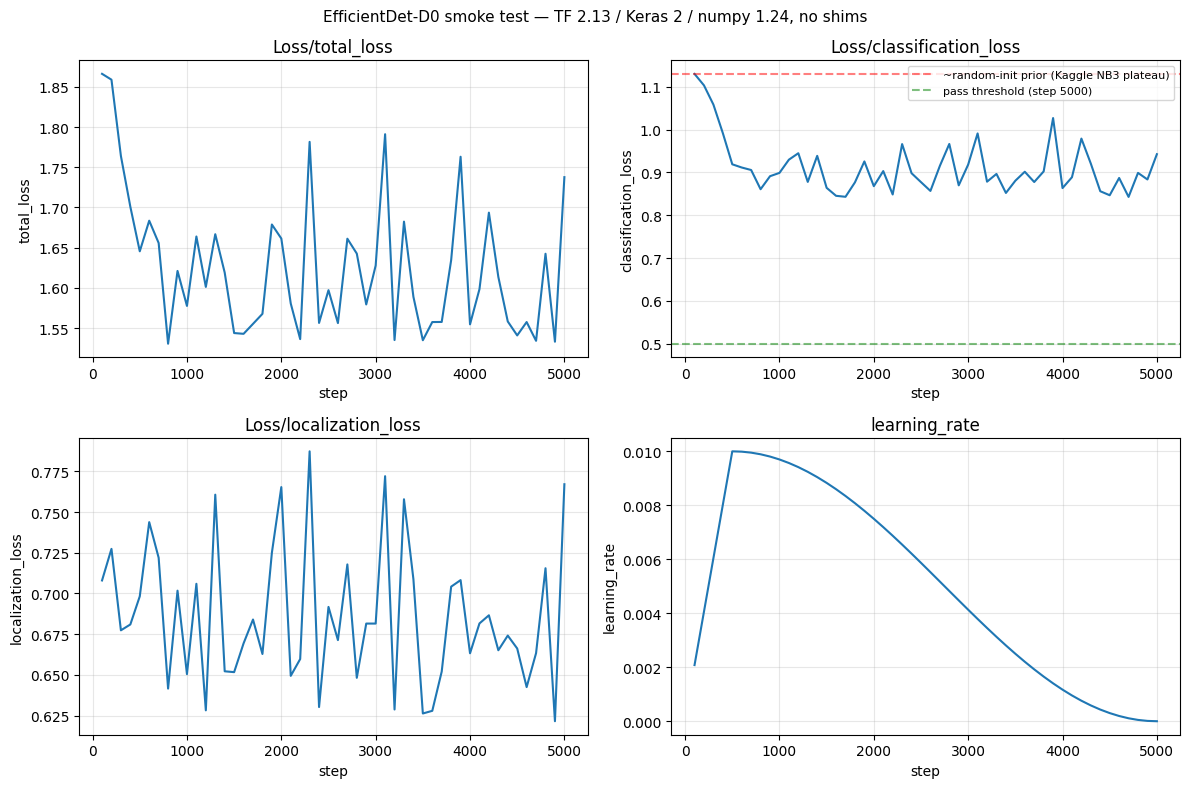


FINAL VERDICT (step 5000, threshold 0.5)
✗ SMOKE TEST FAILED
  classification_loss at step 5000: 0.9424 >= 0.5

  Conclusion: the canonical TF 2.13 + Keras 2 + numpy 1.24 stack
  ALSO fails to restore the EfficientDet COCO-detection checkpoint
  cleanly. Environment is not the (only) cause.

  This rules out the OD-API-on-TF-2.x training stack as a viable
  path to a deployable EfficientDet model within project timelines.
  NB2 on Kaggle reached mAP=0.278 / mAP_small=0.076 which doesn't
  meet the system's recall/precision targets — so 'use SSD anyway'
  is not a fallback.

  Realistic pivots, in order of expected speed-to-result:
    A. Ultralytics YOLO (v8/v11/26) — mature training stack on
       PyTorch, strong small-object performance, clean TFLite +
       EdgeTPU export. Bypasses the OD API entirely.
    B. torchvision SSDLite or timm's EfficientDet — same idea,
       different ecosystem. Slightly more EdgeTPU export work.
    C. Revisit NB2's data/augmentation strategy with t

In [15]:
# Cell #11: Final verdict.
#
# Re-parse the (now extended) event file via subprocess, plot the four
# scalars in the kernel, and apply the confirmed-pass gate.

import json as _json
import subprocess
import matplotlib.pyplot as plt

# Same parse script as Cell #9; results merged with what's already there.
parse_script = f'''
import glob, json, os
import tensorflow as tf

train_events_dir = os.path.join({TRAIN_DIR!r}, "train")
event_files = sorted(glob.glob(os.path.join(train_events_dir, "events.out.tfevents*")))


def _read(v):
    if v.tensor.ByteSize() > 0:
        try:
            return float(tf.make_ndarray(v.tensor))
        except Exception:
            return None
    return v.simple_value


series = {{}}
for path in event_files:
    for event in tf.compat.v1.train.summary_iterator(path):
        for v in event.summary.value:
            val = _read(v)
            if val is None:
                continue
            series.setdefault(v.tag, []).append([event.step, val])

for tag in list(series):
    by_step = {{}}
    for s, v in series[tag]:
        by_step[s] = v
    series[tag] = sorted(by_step.items())

print("__JSON_START__")
print(json.dumps({{"series": series}}))
print("__JSON_END__")
'''

print(">> Re-parsing event files for final verdict...")
result = subprocess.run(['/usr/local/bin/python', '-c', parse_script],
                        capture_output=True, text=True, timeout=120)
if result.returncode != 0:
    print("STDERR:", result.stderr[-1500:])
    raise RuntimeError("Final parse subprocess failed.")
out = result.stdout
i0 = out.index("__JSON_START__") + len("__JSON_START__")
i1 = out.index("__JSON_END__")
series = _json.loads(out[i0:i1].strip())["series"]

for tag in TAGS:
    pts = series.get(tag, [])
    print(f"  {tag}: {len(pts)} points, "
          f"first={pts[0] if pts else None}, "
          f"last={pts[-1] if pts else None}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))


def plot_series(ax, tag, ylabel):
    pts = series.get(tag, [])
    if not pts:
        ax.set_title(f"{tag} (no data)")
        ax.set_xlabel("step"); ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3); return
    steps = [p[0] for p in pts]
    vals = [p[1] for p in pts]
    ax.plot(steps, vals, linewidth=1.5)
    ax.set_xlabel("step"); ax.set_ylabel(ylabel)
    ax.set_title(tag); ax.grid(True, alpha=0.3)


plot_series(axes[0, 0], 'Loss/total_loss', 'total_loss')
plot_series(axes[0, 1], EXPECTED_CLS_TAG, 'classification_loss')
plot_series(axes[1, 0], 'Loss/localization_loss', 'localization_loss')
plot_series(axes[1, 1], 'learning_rate', 'learning_rate')

axes[0, 1].axhline(y=1.13, color='red', linestyle='--', alpha=0.5,
                   label='~random-init prior (Kaggle NB3 plateau)')
axes[0, 1].axhline(y=0.5, color='green', linestyle='--', alpha=0.5,
                   label='pass threshold (step 5000)')
axes[0, 1].legend(fontsize=8)

fig.suptitle("EfficientDet-D0 smoke test — TF 2.13 / Keras 2 / numpy 1.24, no shims",
             fontsize=11)
fig.tight_layout()
fig.savefig("/content/smoke_test_curves.png", dpi=100, bbox_inches='tight')
plt.show()

# Final verdict.
cls_series = series.get(EXPECTED_CLS_TAG, [])
last_step, last_cls = cls_series[-1] if cls_series else (0, float('inf'))

PASS_THRESHOLD = 0.5
SMOKE_TEST_PASSED = (last_step >= NUM_STEPS - 100) and (last_cls < PASS_THRESHOLD)

print("\n" + "=" * 60)
print(f"FINAL VERDICT (step {last_step}, threshold {PASS_THRESHOLD})")
print("=" * 60)
if SMOKE_TEST_PASSED:
    print(f"✓ SMOKE TEST PASSED")
    print(f"  classification_loss at step {last_step}: {last_cls:.4f} < {PASS_THRESHOLD}")
    print(f"")
    print(f"  Conclusion: the TF 2.19/Keras 3/numpy 2 + shim stack on Kaggle WAS")
    print(f"  the root cause of NB3's restoration failure. The canonical TF 2.13")
    print(f"  stack on Colab restores cleanly without shims.")
    print(f"")
    print(f"  IMPORTANT — the smoke test confirms training MECHANICS, not")
    print(f"  deployment performance. The 2K-image generic COCO subset used")
    print(f"  here is not the real dataset and the resulting mAP doesn't")
    print(f"  predict NB3-on-real-data quality. The next steps below produce")
    print(f"  the deployment evaluation.")
    print(f"")
    print(f"  Next steps:")
    print(f"    1. TFRecord transfer from Kaggle NB1 to Colab (~10GB)")
    print(f"       Recommended path: publish NB1 output as a public Kaggle")
    print(f"       Dataset, fetch in Colab via `kaggle datasets download`.")
    print(f"    2. Rebuild NB2 on Colab (SSD MobileNet V2 FPNLite, 640×640)")
    print(f"       — should reproduce Kaggle mAP=0.278 +/- noise; confirms")
    print(f"       Colab/Kaggle parity for non-broken architectures.")
    print(f"    3. Rebuild NB3 on Colab (EfficientDet-D0; revisit 320 vs 384")
    print(f"       vs 512). This is the architecture-side bet for closing")
    print(f"       the mAP_small gap.")
    print(f"    4. Build NB4 (per-pixel-bucket eval + EdgeTPU compile).")
    print(f"    5. If NB3 still doesn't close the small-target gap on real")
    print(f"       data: revisit data strategy (small-bbox augmentation,")
    print(f"       resolution-aware crops) and/or pivot to Ultralytics YOLO.")
else:
    print(f"✗ SMOKE TEST FAILED")
    print(f"  classification_loss at step {last_step}: {last_cls:.4f} >= {PASS_THRESHOLD}")
    print(f"")
    print(f"  Conclusion: the canonical TF 2.13 + Keras 2 + numpy 1.24 stack")
    print(f"  ALSO fails to restore the EfficientDet COCO-detection checkpoint")
    print(f"  cleanly. Environment is not the (only) cause.")
    print(f"")
    print(f"  This rules out the OD-API-on-TF-2.x training stack as a viable")
    print(f"  path to a deployable EfficientDet model within project timelines.")
    print(f"  NB2 on Kaggle reached mAP=0.278 / mAP_small=0.076 which doesn't")
    print(f"  meet the system's recall/precision targets — so 'use SSD anyway'")
    print(f"  is not a fallback.")
    print(f"")
    print(f"  Realistic pivots, in order of expected speed-to-result:")
    print(f"    A. Ultralytics YOLO (v8/v11/26) — mature training stack on")
    print(f"       PyTorch, strong small-object performance, clean TFLite +")
    print(f"       EdgeTPU export. Bypasses the OD API entirely.")
    print(f"    B. torchvision SSDLite or timm's EfficientDet — same idea,")
    print(f"       different ecosystem. Slightly more EdgeTPU export work.")
    print(f"    C. Revisit NB2's data/augmentation strategy with the existing")
    print(f"       OD API pipeline — if mAP_small can be lifted from 0.076 to")
    print(f"       ~0.20+ with better small-bbox augmentation alone, SSD on")
    print(f"       Kaggle becomes deployable without changing stack.")
    print(f"")
    print(f"  Curves saved at /content/smoke_test_curves.png for diagnosis.")
